### imports

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from agents.v7.ppo_agent import ActorCritic
from agents.v7.ppo_agent import PPOAgent
import torch
import numpy as np
import matplotlib.pyplot as plt
import chess.svg
from IPython.display import SVG, display

import utils.board as b

# Notebook 2: The Agent

Network architecture, policy types, and the algorithm progression from REINFORCE to A2C to PPO.

## 1. Why a Neural Network and Not a Q-table?

A Q-table stores a value for every (state, action) pair. For small problems it's fine. For chess it doesn't work.

### The numbers
- KQK has millions of distinct positions. Full chess has more than 10⁴⁰.
- We have 4096 possible actions.
- A Q-table for just 1M KQK states would need ~4 billion entries.
- No generalisation: a position with the king on e4 and one with the king on e5 are completely separate entries, even though the right strategy is nearly identical.

### Why a neural network?
The network has ~700k parameters. Similar positions get similar outputs because the weights are shared. Anything the agent learns in one position carries over to positions that look like it.

In [2]:
table_states  = 1_000_000
table_actions = 4096
q_table_size  = table_states * table_actions

net_params = (768*256 + 256) + (256*256 + 256) + (256*4096 + 4096) + (256 + 1)
print(f"Q-table size (1M states × 4096 actions): {q_table_size:,} entries")
print(f"Neural network parameters:               {net_params:,}")
print(f"Ratio: {q_table_size / net_params:.0f}× more entries in Q-table")

Q-table size (1M states × 4096 actions): 4,096,000,000 entries
Neural network parameters:               1,315,585
Ratio: 3113× more entries in Q-table


## 2. Neural Network Architecture

```
Input (768)
    ↓
Linear(768 → 256) + ReLU
    ↓
Linear(256 → 256) + ReLU
    ↓  ← shared backbone
   / \
Actor    Critic
Linear   Linear
(256→4096) (256→1)
  logits    V(s)
```

### Why share the backbone?
Both the policy (what to play) and the value estimate (how good is this position) need to understand the board. Sharing the lower layers means both heads train on the same representation — fewer parameters, same expressiveness.

### REINFORCE (v1–v4): actor only
The early agents have no critic, just the backbone → 4096 logits. The value head was added in v5 with A2C.

In [3]:
# Show network architecture and parameter breakdown

net = ActorCritic(hidden=256)

print("ActorCritic architecture:")
print(net)
print()
total = 0
for name, p in net.named_parameters():
    print(f"  {name:40s}  shape={str(list(p.shape)):20s}  params={p.numel():,}")
    total += p.numel()
print(f"\nTotal parameters: {total:,}")

ActorCritic architecture:
ActorCritic(
  (backbone): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (actor): Linear(in_features=256, out_features=4096, bias=True)
  (critic): Linear(in_features=256, out_features=1, bias=True)
)

  backbone.0.weight                         shape=[256, 768]            params=196,608
  backbone.0.bias                           shape=[256]                 params=256
  backbone.2.weight                         shape=[256, 256]            params=65,536
  backbone.2.bias                           shape=[256]                 params=256
  actor.weight                              shape=[4096, 256]           params=1,048,576
  actor.bias                                shape=[4096]                params=4,096
  critic.weight                             shape=[1, 256]              params=256
  critic.bias                               shap

## 3. Legal Move Masking

The network outputs 4096 logits. Before sampling, illegal moves are set to −∞:

```python
mask = torch.full((4096,), float('-inf'))
mask[legal_actions] = 0.0
probs = softmax(logits + mask)
```
Legal moves: logit unchanged. Illegal moves: sent to −∞, so softmax gives them probability ≈ 0.

The network can never accidentally pick an illegal move.

## 4. Policy Types

### Stochastic (used during training)
```python
probs  = softmax(logits[legal_actions])
action = multinomial_sample(probs)
```
Random draws proportional to probability. The same position can give different moves needed for exploration.

### Greedy (used during evaluation)
```python
action = legal_actions[argmax(logits[legal_actions])]
```
Always picks the highest-probability move. Deterministic. Used to report checkmate rates.

## 5. Algorithm Progression: REINFORCE → A2C → PPO

### REINFORCE (agents v1–v4)

```
loss = −∑ₜ log π(aₜ|sₜ) · Gₜ
```

`Gₜ` is the discounted return from step t. Increase the probability of moves that appeared in good episodes, decrease it in bad ones.

The problem: `Gₜ` depends on everything that happens after step t, which is noisy. The algorithm learns but slowly.

---

### A2C — Advantage Actor-Critic (agent v5)

Adds a critic `V(s)` that estimates expected return from each position.
The actor updates on the advantage instead:

```
Aₜ = Gₜ − V(sₜ)
```

`Aₜ > 0`: this action did better than expected → increase its probability.  
`Aₜ < 0`: this action did worse than expected → decrease it.

The critic removes the noisy floor from the gradient.

---

### PPO — Proximal Policy Optimization (agents v6–v7)

Limits how much the policy can change per update:

```
ratio = π_new(a|s) / π_old(a|s)
loss  = −min(ratio · A, clip(ratio, 1−ε, 1+ε) · A)
```

If the new policy is pulling too far from the old one, the objective clamps it. Prevents large updates that destabilise training.

PPO also reuses each batch for 4 gradient steps instead of 1, more sample-efficient.

## 6. Future Extensions: Minimax and MCTS

The current policy is just `(obs, legal_actions) → action`. It can be swapped without touching the training loop or the environment.

### Minimax
```python
def minimax_policy(board, depth=3):
    for move in board.legal_moves:
        board.push(move)
        score = -minimax(board, depth - 1, -inf, inf)
        board.pop()
    return best_move
```
No neural network — exhaustive tree search. Slow for large depths, useful as a near-perfect benchmark.

### MCTS (AlphaZero style)
```python
def mcts_policy(board, net, n_simulations=1000):
    root = MCTSNode(board)
    for _ in range(n_simulations):
        root.simulate(net)  # actor head → move prior, critic head → position value
    return root.best_action()
```

### Why not now?
KQK checkmate is reachable in ≤ ~15 moves from any position. A greedy neural policy is enough here. For harder endgames, deeper search will be needed, and the interface already supports swapping it in.

## 7. Demo: Load the Best Agent

In [4]:
MODEL_PATH = "../notebooks/models/kqk_ppo_with_opponent_v1_stage_2.pt"

agent = PPOAgent(curriculum_ratio=0.0)
try:
    agent.net.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
    agent.net.eval()
    print(f"Loaded model from {MODEL_PATH}")
    model_loaded = True
except FileNotFoundError:
    print(f"Model file not found at {MODEL_PATH}")
    print("Proceeding with untrained network for demonstration purposes.")
    model_loaded = False

Using device: cuda
Loaded model from ../notebooks/models/kqk_ppo_with_opponent_v1_stage_2.pt


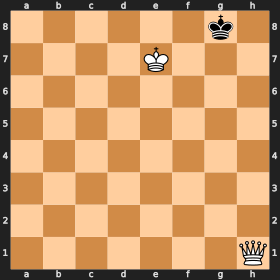

Position value (critic): V(s) = 8.408
Legal moves: 27
Greedy move: Qg1+  (prob = 0.825)


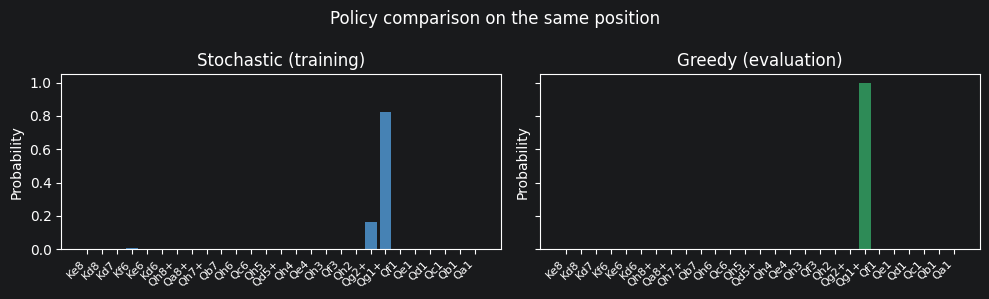

In [5]:
# Show action distributions: stochastic vs greedy on a sample position
DEVICE = next(agent.net.parameters()).device
board  = b.random_kqk_position()
obs    = torch.FloatTensor(b.board_to_obs(board)).unsqueeze(0).to(DEVICE)
legal  = [b.move_to_action(m) for m in board.legal_moves]

with torch.no_grad():
    logits, value = agent.net(obs)
logits = logits.squeeze(0).cpu()
raw    = logits[legal].float()

greedy_idx  = raw.argmax().item()
greedy_act  = legal[greedy_idx]
stoch_probs = torch.softmax(raw, dim=0).numpy()

display(SVG(chess.svg.board(board, size=280)))
print(f"Position value (critic): V(s) = {value.item():.3f}")
print(f"Legal moves: {len(legal)}")
print(f"Greedy move: {board.san(b.action_to_move(greedy_act))}  (prob = {stoch_probs[greedy_idx]:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
moves_san = [board.san(b.action_to_move(a)) for a in legal]
x = range(len(legal))

axes[0].bar(x, stoch_probs, color="steelblue")
axes[0].set_title("Stochastic (training)")
greedy_probs = np.zeros(len(legal)); greedy_probs[greedy_idx] = 1.0
axes[1].bar(x, greedy_probs, color="seagreen")
axes[1].set_title("Greedy (evaluation)")

for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(moves_san, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Probability")
plt.suptitle("Policy comparison on the same position")
plt.tight_layout()
plt.show()

In [6]:
# Animate a full game (interactive in Jupyter)
agent.animate_game(greedy=True, movement_ratio=1.0)